In [1]:
!pip install numpy pandas matplotlib seaborn pyarrow -q

In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.


import os
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'd009_outputs/' 가 만들어집니다)
OUT_DIR = Path("d009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())



준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3
저장 폴더: C:\Users\spide\ai-data-bootcamp\D009\d009_outputs


In [3]:
DATA_DIR = Path(".")
df = pd.read_csv(DATA_DIR /"dirty_cafe_sales.csv")
print(df.shape)
df.info()
df.head(10)

(10000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 1.1 MB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [4]:
# 변환 전 순수 데이터
# 데이터 개요 기록
# str 타입들 숫자형 변환 후 IQR 재검증
# 결측치가 많은 경우 어떻게 처리할 지 고민
# Transaction Date는 날짜형으로 변환
def quality_report(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    '''데이터프레임의 품질을 컬럼별로 진단해 한 표로 돌려줍니다.'''
    n_rows = len(df)
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
        "sample": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns],
    })
        # IQR 이상치 비율 (수치형 컬럼만)
    outlier_pct = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_pct[col] = ((s < lo) | (s > hi)).mean() * 100
    report["outlier_pct_iqr"] = pd.Series(outlier_pct).round(2)

    suspicious_datetime = []
    for col in df.select_dtypes(include="object").columns:
        try:
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().mean() > 0.8:
                suspicious_datetime.append(col)
        except Exception:
            pass
    report["maybe_datetime"] = report.index.isin(suspicious_datetime)

    print(f"[품질 리포트] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  메모리: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    if suspicious_datetime:
        print(f"  📌 날짜로 보이는 object 컬럼: {suspicious_datetime}")
    return report


cafe_sales = quality_report(df, "dirty_cafe_sales.csv")
cafe_sales

[품질 리포트] dirty_cafe_sales.csv
  행 수: 10,000  /  열 수: 8
  메모리: 1083.1 KB
  완전 중복 행: 0건
  📌 날짜로 보이는 object 컬럼: ['Transaction Date']


,dtype,missing,missing_pct,n_unique,sample,outlier_pct_iqr,maybe_datetime
Transaction ID,str,0,0.00,10000,TXN_1961373,NaN,False
Item,str,333,3.33,10,Coffee,NaN,False
Quantity,str,138,1.38,7,2,NaN,False
Price Per Unit,str,179,1.79,8,2.0,NaN,False
Total Spent,str,173,1.73,19,4.0,NaN,False
Payment Method,str,2579,25.79,5,Credit Card,NaN,False
Location,str,3265,32.65,4,Takeaway,NaN,False
Transaction Date,str,159,1.59,367,2023-09-08,NaN,True


In [5]:
# 타입 변환: 숫자형 컬럼과 날짜형 컬럼을 올바른 dtype으로 변환
# ("ERROR", "UNKNOWN" 등 비정상 문자열은 변환 불가하므로 NaN/NaT로 처리됨)
# 숫자로 변경해야하는 칼럼들 변경
num_cols = ["Quantity", "Price Per Unit", "Total Spent"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    
#날짜를 datetime으로 변경
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], format="mixed", errors="coerce")

# 변환 결과 확인
print(df.dtypes)
print()
print(df[num_cols + ["Transaction Date"]].isna().sum())

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

Quantity            479
Price Per Unit      533
Total Spent         502
Transaction Date    460
dtype: int64


In [6]:
# 변환 후 데이터 프레임 품질 진단
def quality_report(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    '''데이터프레임의 품질을 컬럼별로 진단해 한 표로 돌려줍니다.'''
    n_rows = len(df)
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
        "sample": [df[col].dropna().iloc[0] if df[col].notna().any() else None for col in df.columns],
    })
        # IQR 이상치 비율 (수치형 컬럼만)
    outlier_pct = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_pct[col] = ((s < lo) | (s > hi)).mean() * 100
    report["outlier_pct_iqr"] = pd.Series(outlier_pct).round(2)

    print(f"[품질 리포트] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  메모리: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    
    return report

cafe_sales = quality_report(df, "dirty_cafe_sales.csv")
cafe_sales

[품질 리포트] dirty_cafe_sales.csv
  행 수: 10,000  /  열 수: 8
  메모리: 908.9 KB
  완전 중복 행: 0건


,dtype,missing,missing_pct,n_unique,sample,outlier_pct_iqr
Transaction ID,str,0,0.00,10000,TXN_1961373,NaN
Item,str,333,3.33,10,Coffee,NaN
Quantity,float64,479,4.79,5,2.0,0.00
Price Per Unit,float64,533,5.33,6,2.0,0.00
Total Spent,float64,502,5.02,17,4.0,2.73
Payment Method,str,2579,25.79,5,Credit Card,NaN
Location,str,3265,32.65,4,Takeaway,NaN
Transaction Date,datetime64[us],460,4.60,365,2023-09-08 00:00:00,NaN


In [7]:
def explore_columns(df: pd.DataFrame, max_unique_show: int = 20) -> None:
    """컬럼별로 타입, 고유값 개수, 값 분포(혹은 상위 값들)를 출력"""
    for col in df.columns:
        print(f"=== {col} ({df[col].dtype}) ===")
        n_unique = df[col].nunique(dropna=False)
        print(f"고유값 개수: {n_unique}")
        
        if n_unique <= max_unique_show:
            # 고유값이 적으면 전체 분포 출력 (범주형에 적합)
            print(df[col].value_counts(dropna=False))
        else:
            # 고유값이 많으면 요약 통계 또는 샘플만
            if pd.api.types.is_numeric_dtype(df[col]):
                print(df[col].describe())
            else:
                print(df[col].dropna().unique()[:10], "...")
        print()

explore_columns(df)

=== Transaction ID (str) ===
고유값 개수: 10000
<ArrowStringArray>
['TXN_1961373', 'TXN_4977031', 'TXN_4271903', 'TXN_7034554', 'TXN_3160411',
 'TXN_2602893', 'TXN_4433211', 'TXN_6699534', 'TXN_4717867', 'TXN_2064365']
Length: 10, dtype: str ...

=== Item (str) ===
고유값 개수: 11
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

=== Quantity (float64) ===
고유값 개수: 6
Quantity
5.0    2013
2.0    1974
4.0    1863
3.0    1849
1.0    1822
NaN     479
Name: count, dtype: int64

=== Price Per Unit (float64) ===
고유값 개수: 7
Price Per Unit
3.0    2429
4.0    2331
2.0    1227
5.0    1204
1.0    1143
1.5    1133
NaN     533
Name: count, dtype: int64

=== Total Spent (float64) ===
고유값 개수: 18
Total Spent
6.0     979
12.0    939
3.0     930
4.0     923
20.0    746
15.0    734
8.0     677
10.0    524
NaN     502
2.0     497
9.0     479
5.0     46

In [8]:
# --- Quantity / Price Per Unit: 허용값 기반 플래그 ---
valid_quantity = {1, 2, 3, 4, 5}
valid_price = {1, 1.5, 2, 3, 4, 5}

df["quantity_invalid"] = ~df["Quantity"].isin(valid_quantity) & df["Quantity"].notna()
df["price_invalid"] = ~df["Price Per Unit"].isin(valid_price) & df["Price Per Unit"].notna()

print("Quantity 허용값 외 이상치:", df["quantity_invalid"].sum())
print("Price Per Unit 허용값 외 이상치:", df["price_invalid"].sum())

# --- Total Spent: IQR 플래그 (제거 X) + 계산값 검증 ---
q1, q3 = df["Total Spent"].quantile(0.25), df["Total Spent"].quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

df["total_spent_iqr_flag"] = (df["Total Spent"] < lo) | (df["Total Spent"] > hi)

expected = df["Quantity"] * df["Price Per Unit"]
df["total_spent_mismatch"] = (
    df["Total Spent"].notna() & expected.notna() &
    (df["Total Spent"].round(2) != expected.round(2))
)

print("Total Spent IQR 플래그 개수:", df["total_spent_iqr_flag"].sum())
print("Total Spent 계산 불일치 개수:", df["total_spent_mismatch"].sum())
print("IQR 플래그 & 계산 불일치 둘 다인 경우:", (df["total_spent_iqr_flag"] & df["total_spent_mismatch"]).sum())

Quantity 허용값 외 이상치: 0
Price Per Unit 허용값 외 이상치: 0
Total Spent IQR 플래그 개수: 259
Total Spent 계산 불일치 개수: 0
IQR 플래그 & 계산 불일치 둘 다인 경우: 0


=== Quantity ===
결측치 개수: 479
count    9521.000000
mean        3.028463
std         1.419007
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64
왜도(skewness): -0.008

=== Price Per Unit ===
결측치 개수: 533
count    9467.000000
mean        2.949984
std         1.278450
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Price Per Unit, dtype: float64
왜도(skewness): 0.005



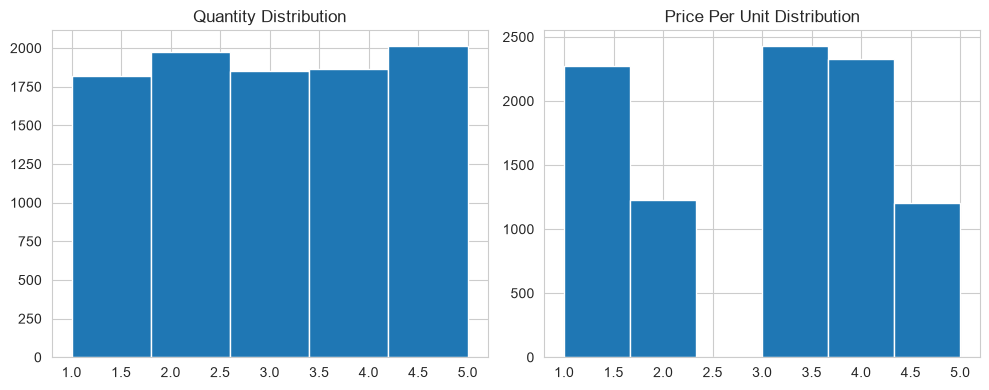

In [9]:
# Quantity와 Price Per Unit 컬럼의 결측치 개수, 분포 확인
for col in ["Quantity", "Price Per Unit"]:
    print(f"=== {col} ===")
    print("결측치 개수:", df[col].isna().sum())
    print(df[col].describe())
    print("왜도(skewness):", df[col].skew().round(3))
    print()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["Quantity"].dropna().hist(bins=5, ax=axes[0])
axes[0].set_title("Quantity Distribution")
df["Price Per Unit"].dropna().hist(bins=6, ax=axes[1])
axes[1].set_title("Price Per Unit Distribution")
plt.tight_layout()
plt.show()

In [10]:
# Quantity와 Price Per Unit 컬럼의 중앙값(median)과 최빈값(mode) 확인

for col in ["Quantity", "Price Per Unit"]:
    median_val = df[col].median()
    mode_val = df[col].mode()[0]
    print(f"{col}: median={median_val}, mode={mode_val}")
    print(df[col].value_counts(normalize=True).sort_index().round(3))
    print()

Quantity: median=3.0, mode=5.0
Quantity
1.0    0.191
2.0    0.207
3.0    0.194
4.0    0.196
5.0    0.211
Name: proportion, dtype: float64

Price Per Unit: median=3.0, mode=3.0
Price Per Unit
1.0    0.121
1.5    0.120
2.0    0.130
3.0    0.257
4.0    0.246
5.0    0.127
Name: proportion, dtype: float64



In [11]:
# Item별 Price Per Unit이 고정되어 있는지 확인
# 보통 메뉴에 따라서 가격이 결정되어있기 때문에 이를 통해 별도의 그룹을 만들어야 될 수도 있음
print(df.groupby("Item")["Price Per Unit"].agg(["nunique", "median", lambda x: x.mode()[0]]))

          nunique  median  <lambda_0>
Item                                 
Cake            1     3.0         3.0
Coffee          1     2.0         2.0
Cookie          1     1.0         1.0
ERROR           6     3.0         3.0
Juice           1     3.0         3.0
Salad           1     5.0         5.0
Sandwich        1     4.0         4.0
Smoothie        1     4.0         4.0
Tea             1     1.5         1.5
UNKNOWN         6     3.0         3.0


In [12]:
# Item별 고정 가격 매핑 만들기 (Unknown 제외)
price_map = (
    df[df["Item"] != "Unknown"]
    .groupby("Item")["Price Per Unit"]
    .median()
)
print(price_map)

# Price Per Unit이 결측인 행 중, Item을 알 수 있는 경우 매핑값으로 채우기
mask = df["Price Per Unit"].isna() & df["Item"].isin(price_map.index)
df.loc[mask, "Price Per Unit"] = df.loc[mask, "Item"].map(price_map)

print("남은 결측치:", df["Price Per Unit"].isna().sum())

Item
Cake        3.0
Coffee      2.0
Cookie      1.0
ERROR       3.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
UNKNOWN     3.0
Name: Price Per Unit, dtype: float64
남은 결측치: 23


In [13]:
# 남은 결측치를 전체 Price Per Unit 중앙값으로 채우기
overall_median = df["Price Per Unit"].median()
print("전체 중앙값:", overall_median)

df["Price Per Unit"] = df["Price Per Unit"].fillna(overall_median)

# 확인
print("남은 결측치:", df["Price Per Unit"].isna().sum())

전체 중앙값: 3.0
남은 결측치: 0


In [14]:
# 비교용 스냅샷 (Quantity 채우기 전)
before_snapshot = df[["Quantity", "Price Per Unit"]].copy()

# Quantity 결측치 중앙값으로 채우기
quantity_median = df["Quantity"].median()
print("Quantity 중앙값:", quantity_median)
df["Quantity"] = df["Quantity"].fillna(quantity_median)

# --- 정제 전/후 비교 ---
comparison = pd.DataFrame({
    "missing_before": before_snapshot.isna().sum(),
    "missing_after": df[["Quantity", "Price Per Unit"]].isna().sum(),
    "mean_before": before_snapshot.mean(),
    "mean_after": df[["Quantity", "Price Per Unit"]].mean(),
    "median_before": before_snapshot.median(),
    "median_after": df[["Quantity", "Price Per Unit"]].median(),
    "std_before": before_snapshot.std(),
    "std_after": df[["Quantity", "Price Per Unit"]].std(),
})
print(comparison.round(3))

Quantity 중앙값: 3.0
                missing_before  missing_after  mean_before  mean_after  \
Quantity                   479              0        3.028       3.027   
Price Per Unit               0              0        2.948       2.948   

                median_before  median_after  std_before  std_after  
Quantity                  3.0           3.0       1.419      1.385  
Price Per Unit            3.0           3.0       1.277      1.277  


In [15]:
# 현재 상태(중앙값 대체까지 완료된 df) 기준 재계산
# 다시 계산한 이유
# price per unit과 quantity를 변경했기 때문에 total spent = quantity * price per unit 의 결과값에 영향을 줬을수 있음
expected = df["Quantity"] * df["Price Per Unit"]
mismatch = df["Total Spent"].notna() & (df["Total Spent"].round(2) != expected.round(2))

print("불일치 건수:", mismatch.sum())
print(df.loc[mismatch, ["Item", "Quantity", "Price Per Unit", "Total Spent"]].head(20))

불일치 건수: 396
         Item  Quantity  Price Per Unit  Total Spent
20   Smoothie       3.0             4.0         20.0
55     Cookie       3.0             1.0          2.0
57       Cake       3.0             3.0          3.0
66      Juice       3.0             3.0          6.0
151       NaN       4.0             3.0         16.0
153   UNKNOWN       3.0             3.0         12.0
177     Salad       3.0             5.0         25.0
178  Smoothie       3.0             4.0         16.0
198     Juice       3.0             3.0         12.0
214     Salad       3.0             5.0         25.0
274  Sandwich       3.0             4.0         16.0
287    Coffee       3.0             2.0          8.0
289       NaN       4.0             3.0          6.0
313    Cookie       3.0             1.0          1.0
334       NaN       4.0             3.0          6.0
340    Cookie       3.0             1.0          1.0
376    Coffee       3.0             2.0          4.0
412     Juice       3.0           

In [16]:
# 1) 중앙값으로 채워졌던 행들 다시 찾기 (quantity_median과 값이 같은 행 = 채워진 행으로 추정)
quantity_median = df["Quantity"].median()

# 2) 역산 가능한 행: mismatch 상태이면서 Price Per Unit != 0
can_backcalc = mismatch & df["Price Per Unit"].notna() & (df["Price Per Unit"] != 0)

# 3) Total Spent / Price Per Unit으로 Quantity 재계산
df.loc[can_backcalc, "Quantity"] = (
    df.loc[can_backcalc, "Total Spent"] / df.loc[can_backcalc, "Price Per Unit"]
).round(0)

print("역산으로 재교정한 개수:", can_backcalc.sum())

# 4) 재검증
expected = df["Quantity"] * df["Price Per Unit"]
mismatch_after = df["Total Spent"].notna() & (df["Total Spent"].round(2) != expected.round(2))
print("재교정 후 남은 불일치 건수:", mismatch_after.sum())

역산으로 재교정한 개수: 396
재교정 후 남은 불일치 건수: 21


In [17]:
# Total Spent 결측치 → Quantity × Price Per Unit으로 정확히 계산
mask_total_na = df["Total Spent"].isna()

df.loc[mask_total_na, "Total Spent"] = (
    df.loc[mask_total_na, "Quantity"] * df.loc[mask_total_na, "Price Per Unit"]
)

print("Total Spent 남은 결측치:", df["Total Spent"].isna().sum())

Total Spent 남은 결측치: 0


In [18]:
# Item 컬럼 결측치 처리
df["Item"] = df["Item"].replace({"ERROR": "Unknown", "UNKNOWN": "Unknown"})
df["Item"] = df["Item"].fillna("Unknown")


print(df["Item"].value_counts(dropna=False))

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Unknown      969
Name: count, dtype: int64


In [19]:
# Payment Method과 Location 컬럼에서 ERROR/UNKNOWN을 "Unknown" 카테고리로 통일 (원래 NaN도 포함)
for col in ["Payment Method", "Location"]:
    df[col] = df[col].replace({"ERROR": "Unknown", "UNKNOWN": "Unknown"})
    df[col] = df[col].fillna("Unknown")

print(df["Payment Method"].value_counts(dropna=False))
print(df["Location"].value_counts(dropna=False))

Payment Method
Unknown           3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64
Location
Unknown     3961
Takeaway    3022
In-store    3017
Name: count, dtype: int64


In [20]:
# 1단계: 순수 원본
df_raw = pd.read_csv("dirty_cafe_sales.csv")

# 2단계: 타입 변환만 한 상태 (표기 혼재 처리 전)
df_typed = df_raw.copy()
num_cols = ["Quantity", "Price Per Unit", "Total Spent"]
for col in num_cols:
    df_typed[col] = pd.to_numeric(df_typed[col], errors="coerce")
df_typed["Transaction Date"] = pd.to_datetime(df_typed["Transaction Date"], errors="coerce")

# 3단계: 표기 혼재까지 전부 정리한 최종 df (지금 갖고 계신 것)

# 3단계 비교
report_raw = quality_report(df_raw, "1. 원본")
report_typed = quality_report(df_typed, "2. 타입변환 후")
report_final = quality_report(df, "3. 최종 정제 후")

comparison = pd.DataFrame({
    "missing_pct_raw": report_raw["missing_pct"],
    "missing_pct_typed": report_typed["missing_pct"],
    "missing_pct_final": report_final["missing_pct"],
})
print(comparison)

[품질 리포트] 1. 원본
  행 수: 10,000  /  열 수: 8
  메모리: 1083.1 KB
  완전 중복 행: 0건
[품질 리포트] 2. 타입변환 후
  행 수: 10,000  /  열 수: 8
  메모리: 908.9 KB
  완전 중복 행: 0건
[품질 리포트] 3. 최종 정제 후
  행 수: 10,000  /  열 수: 12
  메모리: 988.4 KB
  완전 중복 행: 0건
                      missing_pct_raw  missing_pct_typed  missing_pct_final
Item                             3.33               3.33                0.0
Location                        32.65              32.65                0.0
Payment Method                  25.79              25.79                0.0
Price Per Unit                   1.79               5.33                0.0
Quantity                         1.38               4.79                0.0
Total Spent                      1.73               5.02                0.0
Transaction Date                 1.59               4.60                4.6
Transaction ID                   0.00               0.00                0.0
price_invalid                     NaN                NaN                0.0
quantity_invalid   

In [21]:
# IQR 이상치 플래그와 계산 불일치 플래그 컬럼은 분석에 필요 없으므로 제거
df = df.drop(columns=["price_invalid", "quantity_invalid", "total_spent_iqr_flag", "total_spent_mismatch"])

print(df.columns.tolist())

['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


In [22]:
final_report = quality_report(df, "최종 정제 결과")
final_report

[품질 리포트] 최종 정제 결과
  행 수: 10,000  /  열 수: 8
  메모리: 949.3 KB
  완전 중복 행: 0건


,dtype,missing,missing_pct,n_unique,sample,outlier_pct_iqr
Transaction ID,str,0,0.0,10000,TXN_1961373,NaN
Item,str,0,0.0,9,Coffee,NaN
Quantity,float64,0,0.0,7,2.0,0.01
Price Per Unit,float64,0,0.0,6,2.0,0.00
Total Spent,float64,0,0.0,17,4.0,2.69
Payment Method,str,0,0.0,4,Credit Card,NaN
Location,str,0,0.0,3,Takeaway,NaN
Transaction Date,datetime64[us],460,4.6,365,2023-09-08 00:00:00,NaN


In [23]:
# 월별 판매 추이
df["order_month"] = df["Transaction Date"].dt.to_period("M").astype(str)

pivot_month = df.pivot_table(
    index="order_month",
    values="Total Spent",
    aggfunc=["sum", "count", "mean"]
).round(2)
pivot_month.columns = ["total_revenue", "n_orders", "avg_order_value"]

print(pivot_month)

             total_revenue  n_orders  avg_order_value
order_month                                          
2023-01             7284.0       818             8.90
2023-02             6656.0       727             9.16
2023-03             7225.0       827             8.74
2023-04             7203.0       774             9.31
2023-05             7011.5       777             9.02
2023-06             7359.0       818             9.00
2023-07             6885.0       791             8.70
2023-08             7115.5       803             8.86
2023-09             6889.0       788             8.74
2023-10             7326.0       838             8.74
2023-11             6967.0       784             8.89
2023-12             7210.0       795             9.07


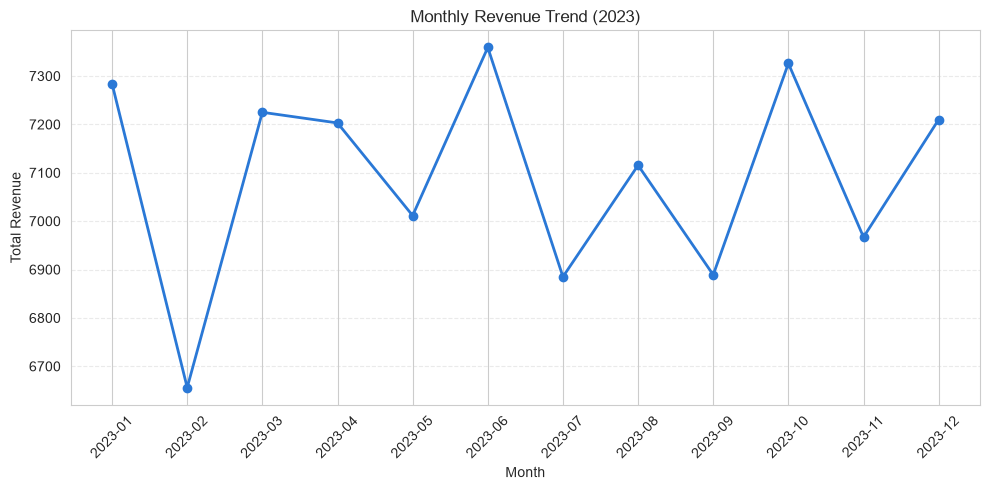

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pivot_month.index, pivot_month["total_revenue"], marker="o", linewidth=2, color="#2a78d6")

ax.set_title("Monthly Revenue Trend (2023)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# 메뉴별 매출 분석
pivot_item = df.pivot_table(
    index="Item",
    values=["Quantity", "Total Spent"],
    aggfunc="sum"
).round(1)

pivot_item = pivot_item.rename(columns={"Quantity": "total_qty_sold", "Total Spent": "total_revenue"})
pivot_item = pivot_item.sort_values("total_revenue", ascending=False)

print(pivot_item)

          total_qty_sold  total_revenue
Item                                   
Salad             3475.0        17375.0
Sandwich          3441.0        13764.0
Smoothie          3342.0        13368.0
Juice             3514.0        10542.0
Cake              3471.0        10413.0
Unknown           2899.0         8537.5
Coffee            3551.0         7102.0
Tea               3310.0         4965.0
Cookie            3238.0         3238.0


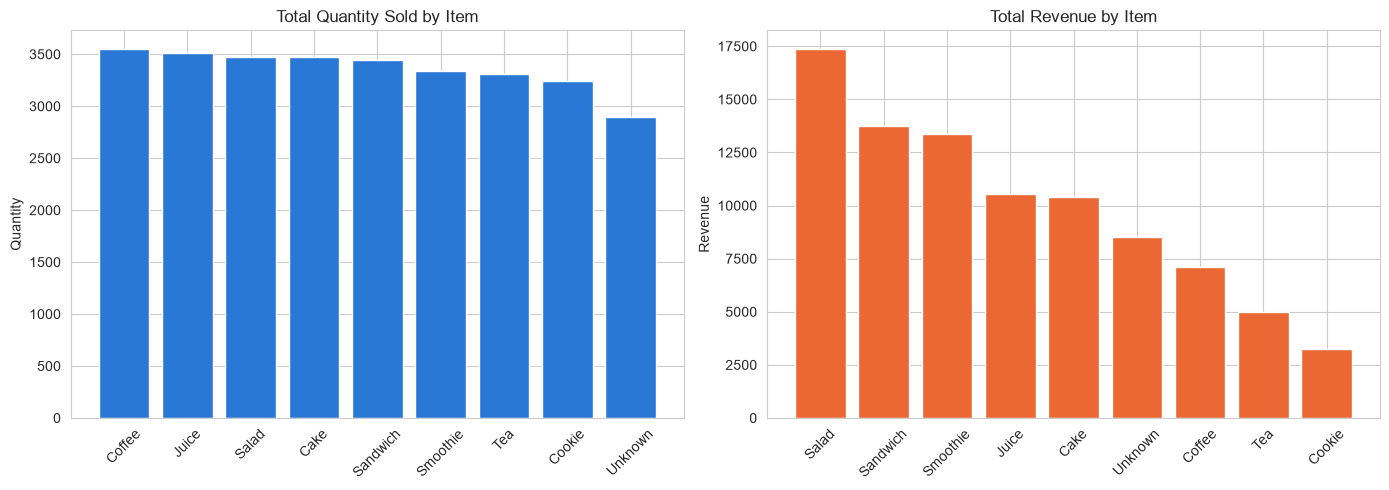

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 판매량
pivot_item_qty = pivot_item.sort_values("total_qty_sold", ascending=False)
axes[0].bar(pivot_item_qty.index, pivot_item_qty["total_qty_sold"], color="#2a78d6")
axes[0].set_title("Total Quantity Sold by Item")
axes[0].set_ylabel("Quantity")
axes[0].tick_params(axis="x", rotation=45)

# 매출
axes[1].bar(pivot_item.index, pivot_item["total_revenue"], color="#eb6834")
axes[1].set_title("Total Revenue by Item")
axes[1].set_ylabel("Revenue")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [27]:
# 요일별 매출 분석
df["order_weekday"] = df["Transaction Date"].dt.day_name()

pivot_weekday = df.pivot_table(
    index="order_weekday",
    values="Total Spent",
    aggfunc=["sum", "count", "mean"]
).round(2)
pivot_weekday.columns = ["total_revenue", "n_orders", "avg_order_value"]

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_weekday = pivot_weekday.reindex(weekday_order)

print(pivot_weekday)

               total_revenue  n_orders  avg_order_value
order_weekday                                          
Monday               12164.0      1382             8.80
Tuesday              12071.0      1311             9.21
Wednesday            11695.5      1341             8.72
Thursday             12446.5      1380             9.02
Friday               12373.0      1388             8.91
Saturday             12075.5      1358             8.89
Sunday               12305.5      1380             8.92


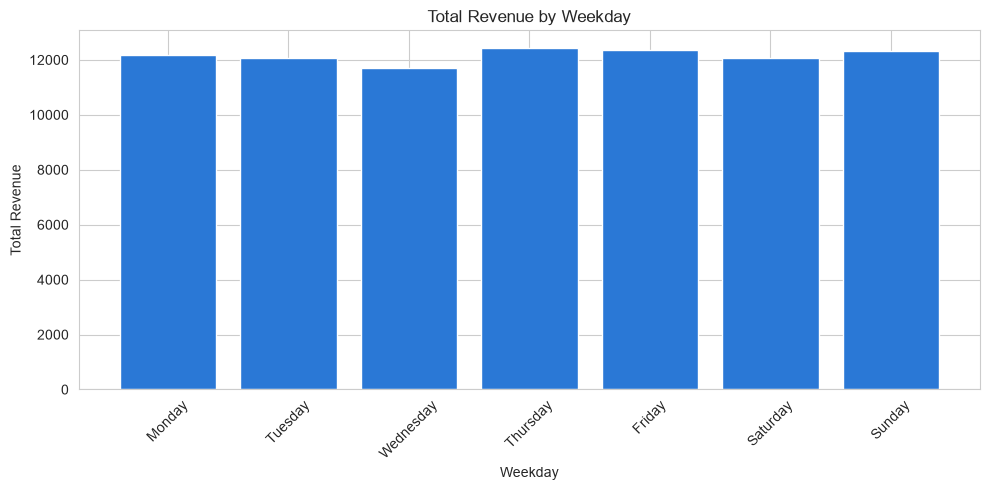

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pivot_weekday.index, pivot_weekday["total_revenue"], color="#2a78d6")
ax.set_title("Total Revenue by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# 저장할 KPI 결과들
pivot_month.to_csv("monthly_revenue.csv")
pivot_month.to_parquet("monthly_revenue.parquet")

pivot_item.to_csv("item_sales.csv")
pivot_item.to_parquet("item_sales.parquet")

pivot_weekday.to_csv("weekday_revenue.csv")
pivot_weekday.to_parquet("weekday_revenue.parquet")

# 용량 비교 (한 줄씩)
for name in ["monthly_revenue", "item_sales", "weekday_revenue"]:
    csv_size = os.path.getsize(f"{name}.csv")
    parquet_size = os.path.getsize(f"{name}.parquet")
    print(f"{name}: CSV {csv_size} bytes / Parquet {parquet_size} bytes → Parquet이 {csv_size/parquet_size:.1f}배 작음")

monthly_revenue: CSV 349 bytes / Parquet 3565 bytes → Parquet이 0.1배 작음
item_sales: CSV 236 bytes / Parquet 2836 bytes → Parquet이 0.1배 작음
weekday_revenue: CSV 243 bytes / Parquet 3505 bytes → Parquet이 0.1배 작음


In [30]:
# outputs 폴더에 KPI 결과를 저장
OUT_DIR = Path("d009_outputs")

pivot_month.to_csv(OUT_DIR / "monthly_revenue.csv")
pivot_month.to_parquet(OUT_DIR / "monthly_revenue.parquet")

pivot_item.to_csv(OUT_DIR / "item_sales.csv")
pivot_item.to_parquet(OUT_DIR / "item_sales.parquet")

pivot_weekday.to_csv(OUT_DIR / "weekday_revenue.csv")
pivot_weekday.to_parquet(OUT_DIR / "weekday_revenue.parquet")

In [31]:
# 최종 정제된 데이터프레임을 CSV로 저장
OUT_DIR = Path("d009_outputs")
df.to_csv(OUT_DIR / "dirty_cafe_sales_cleaned.csv", index=False)

In [32]:
import os
print(os.getcwd())          # 지금 작업 디렉토리
print(os.listdir("."))      # 이 안에 pipeline.py가 보이는지 확인

c:\Users\spide\ai-data-bootcamp\D009
['d009_outputs', 'day9-capstone.ipynb', 'day9-report.md', 'dirty_cafe_sales.csv', 'dirty_cafe_sales_cleaned.csv', 'item_sales.csv', 'item_sales.parquet', 'monthly_revenue.csv', 'monthly_revenue.parquet', 'pipeline.py', 'weekday_revenue.csv', 'weekday_revenue.parquet', '__pycache__']


In [33]:
# 파이프라인 호출
from pipeline import full_pipeline
from pathlib import Path

log = full_pipeline(
    input_path=Path("dirty_cafe_sales.csv"),
    output_dir=Path(".")
)

for k, v in log.items():
    print(f"{k}: {v}")

[결정로그] convert_types: Quantity → 숫자형 변환 (errors='coerce') (341건) — ERROR/UNKNOWN 등 숫자로 변환 불가능한 문자열은 NaN 처리
[결정로그] convert_types: Price Per Unit → 숫자형 변환 (errors='coerce') (354건) — ERROR/UNKNOWN 등 숫자로 변환 불가능한 문자열은 NaN 처리
[결정로그] convert_types: Total Spent → 숫자형 변환 (errors='coerce') (329건) — ERROR/UNKNOWN 등 숫자로 변환 불가능한 문자열은 NaN 처리
[결정로그] convert_types: Transaction Date → datetime 변환 (errors='coerce') (301건) — 날짜 형식이 아닌 문자열은 NaT 처리
[결정로그] clean_categorical: Item: ERROR/UNKNOWN/NaN → 'Unknown' 통일 (969건) — 표기 혼재를 하나의 결측 카테고리로 정리 (컬럼 유지가 삭제보다 정보 손실 적음)
[결정로그] clean_categorical: Payment Method: ERROR/UNKNOWN/NaN → 'Unknown' 통일 (3178건) — 표기 혼재를 하나의 결측 카테고리로 정리 (컬럼 유지가 삭제보다 정보 손실 적음)
[결정로그] clean_categorical: Location: ERROR/UNKNOWN/NaN → 'Unknown' 통일 (3961건) — 표기 혼재를 하나의 결측 카테고리로 정리 (컬럼 유지가 삭제보다 정보 손실 적음)
[결정로그] fill_price_per_unit: Item별 고정 가격으로 채움 (479건) — 메뉴별 가격이 1개 값으로 고정되어 있음이 확인되어, 추정이 아닌 정확한 복원
[결정로그] fill_price_per_unit: 남은 결측치 → 전체 중앙값으로 채움 (54건) — Item도 Unknown이라 가격을 특정할 근거가 없는 경우
[결정

In [37]:
from pathlib import Path

OUT_DIR = Path("d009_outputs")

decisions = pipeline.DECISION_LOG

md_table = "| 단계 | 결정 내용 | 근거 | 영향 건수 |\n|---|---|---|---|\n"
for d in decisions:
    md_table += f"| {d['step']} | {d['decision']} | {d['reason']} | {d['count']}건 |\n"

with open(OUT_DIR / "decision_log.md", "w", encoding="utf-8") as f:
    f.write("# 정제 결정 로그\n\n")
    f.write(md_table)

print("저장 완료:", OUT_DIR / "decision_log.md")

저장 완료: d009_outputs\decision_log.md
